# Score Linhas

O objetivo deste notebook é atribuir pontuações de risco para cada linha de ônibus do município do Rio de Janeiro.

## Métrica de pontuação

A métrica atualmente adotada é dada por: $$\frac{\sum_{i} d_i* (3r_i+f_i)}{\sum_{i} d_i} $$ onde $d_i$ representa a distância que a linha percorre na cisp i e $r_i$ é o risco daquela cisp. O risco de cada cisp é  dado pela soma do número de ocorrências ocorridas naquela região no ultimo ano, ponderado pelo peso. Adotamos peso 2 para roubose peso 1 para furtos, pois roubos sao mais violentos e portanto piores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sklearn

In [22]:
with open("../datasets/dados_finais.pkl","rb") as file:
    df = pickle.load(file)
df = df[["cisp","furto_coletivo","roubo_em_coletivo","ano"]]
df.head()

,cisp,furto_coletivo,roubo_em_coletivo,ano
0,1,12.0,5.0,2014
1,1,23.0,1.0,2014
2,1,17.0,4.0,2014
3,1,7.0,4.0,2014
4,1,8.0,4.0,2014


In [27]:
#somando ao longo dos 12 meses 
df_score = df[df["ano"]==2027]
df_score = df.groupby("cisp")[["furto_coletivo", "roubo_em_coletivo"]].sum().assign(score=lambda x: x["furto_coletivo"] + (x["roubo_em_coletivo"] * 3))["score"]
df_score

cisp
1      5248.211283
4     13120.269745
5      6427.955421
6     10540.984872
7      1147.947838
9      6941.122937
10     8459.285384
11      940.162326
12     4948.418199
13     2562.718619
14     3340.863146
15     3927.124376
16    15399.568133
17    18753.947734
18     9236.758977
19     5458.709885
20     4523.954183
21    29061.092002
22     9128.760132
23     3808.940562
24     3483.215422
25     9201.936788
26     4037.500876
27    10561.591985
28     4314.470149
29    16305.563770
30     4635.828915
31     6600.408897
32    15693.746385
33     6694.854339
34    10646.969357
35     8151.716032
36     5742.286238
37     3984.431217
38     7271.109566
39    16438.376317
40     9341.472032
41     4090.774998
42     5518.596846
43     2928.908385
44     5300.226283
Name: score, dtype: float64

#### calculando score das linhas

In [28]:
with open("../datasets/linhas_cisps.pkl","rb") as file:
    rotas = pickle.load(file)
rotas.head()

,route_id,shape_id,distancia_por_cisp,route_short_name,route_long_name
0,E2336AAA0A,ab43,"[(40, 1.52), (5, 2.06), (27, 1.91), (1, 0.17),...",2336,Campo Grande - Castelo
1,O0629AAA0A,ue02,"[(21, 2.13), (25, 4.88), (27, 5.54), (38, 1.08...",629,Irajá - Saens Peña
2,O0774AAA0A,i9sp,"[(38, 7.94), (27, 4.65), (29, 4.88), (27, 4.64...",774,Madureira - Jardim América
3,O0112AAA0A,O0112AAA0AVDU03,"[(6, 5.81), (18, 0.05), (15, 4.91), (4, 1.31),...",112,Terminal Gentileza - Alto Gávea
4,O0343AAA0A,j7v9,"[(18, 0.05), (26, 2.32), (1, 1.8), (4, 1.31), ...",343,Jardim Oceânico - Candelária


In [29]:
rotas = rotas.drop_duplicates(subset="route_id")
(rotas[rotas["route_short_name"]=="232"])

,route_id,shape_id,distancia_por_cisp,route_short_name,route_long_name
377,O0232AAA0A,9ptt,"[(5, 2.23), (18, 3.14), (5, 2.24), (1, 1.09), ...",232,Lins de Vasconcelos - Castelo


In [30]:
def calcular_score_ponderado(rota, riscos):
    if not rota:
        return 0
    soma_ponderada = 0
    soma_distancias = 0
    for cisp, distancia in rota:
        if cisp in riscos.index:
            risco = riscos.loc[cisp]
            soma_ponderada += (risco * distancia)
            soma_distancias += distancia
    return soma_ponderada / soma_distancias if soma_distancias > 0 else 0
rotas['score'] = rotas['distancia_por_cisp'].apply(lambda x: calcular_score_ponderado(x, df_score))

### Vizualizando score de linhas

<Axes: >

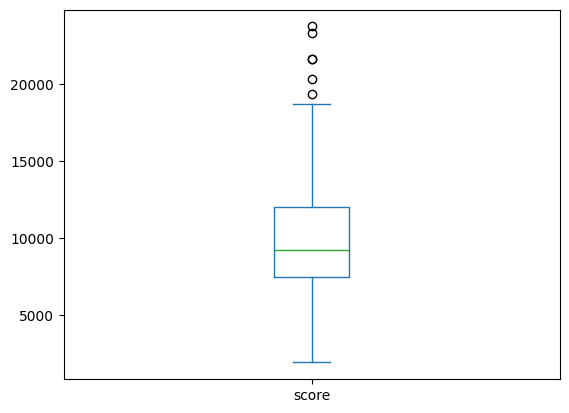

In [31]:
rotas["score"].plot.box()

In [32]:
rotas

,route_id,shape_id,distancia_por_cisp,route_short_name,route_long_name,score
0,E2336AAA0A,ab43,"[(40, 1.52), (5, 2.06), (27, 1.91), (1, 0.17),...",2336,Campo Grande - Castelo,12941.747716
1,O0629AAA0A,ue02,"[(21, 2.13), (25, 4.88), (27, 5.54), (38, 1.08...",629,Irajá - Saens Peña,10057.078728
2,O0774AAA0A,i9sp,"[(38, 7.94), (27, 4.65), (29, 4.88), (27, 4.64...",774,Madureira - Jardim América,11668.978734
3,O0112AAA0A,O0112AAA0AVDU03,"[(6, 5.81), (18, 0.05), (15, 4.91), (4, 1.31),...",112,Terminal Gentileza - Alto Gávea,8099.313933
4,O0343AAA0A,j7v9,"[(18, 0.05), (26, 2.32), (1, 1.8), (4, 1.31), ...",343,Jardim Oceânico - Candelária,13270.796793
...,...,...,...,...,...,...
1717,SE010,uijs,"[(41, 0.84), (32, 7.9), (28, 3.04), (30, 0.77)...",SE010,Terminal Paulo da Portela - Estação Morro do O...,11893.581237
1726,O0862AAN0A,O0862AAA0AIDU01,"[(32, 0.9), (16, 14.28)]",SN862,Rio das Pedras - Barra da Tijuca,15417.009531
1741,O0393AAE0A,58du,"[(1, 1.12), (39, 2.3), (17, 4.14), (4, 0.87), ...",SE393,Bangu - Enseada de Botafogo,12732.226657
1743,O0238AAE0A,i40u,"[(7, 0.36), (9, 3.3), (12, 1.47), (19, 1.29), ...",SE238,Água Santa - Enseada de Botafogo,6354.750826


In [51]:
(rotas[rotas["score"]>=17000]).sort_values(by="score")[["route_short_name","route_long_name"]]

,route_short_name,route_long_name
245,665,Pavuna - Saens Peña
1285,663,Méier - Fundão
497,210,Caju - Candelária
361,312,Olaria - Candelária
489,209,Candelária - Caju
260,313,Penha (Grotão) - Praça Tiradentes
521,906,Jardim América - Caju
1178,71,Vigário Geral - Terminal Gentileza
1646,73,Terminal Margaridas - Terminal Gentileza
508,335,Cordovil - Tiradentes


In [50]:
rotas.to_pickle("../datasets/rotas_riscos.pkl")